In [1089]:
import pandas as pd
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import OLSInfluence
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Lasso, LassoCV
from statsmodels.stats.anova import anova_lm

In [1090]:
# Load dataset
df = pd.read_csv("Dataset/academic_meals_elementary_district.csv")

print("Original shape:", df.shape)

Original shape: (54, 263)


In [1091]:
total_nulls = df.isnull().sum().sum()

print("Total missing values in dataset:", total_nulls)

Total missing values in dataset: 1


In [1092]:
null_per_column = df.isnull().sum()

print(null_per_column)

District                         0
ROE                              0
student_disabilities_percent     1
student_low_income_percent       0
days_entered.x                   0
                                ..
Science_Proficiency              0
Science_Proficiency_LowIncome    0
Science_Proficiency_CWD          0
missing_frac                     0
missing_count                    0
Length: 263, dtype: int64


In [1093]:
# Check which row has missing value
df[df["student_disabilities_percent"].isnull()]

,District,ROE,student_disabilities_percent,student_low_income_percent,days_entered.x,HEI 2015 Total Score,HEI 2015 Total Fruits (0-5),HEI 2015 Whole Fruits (0-5),HEI 2015 Total Vegetables (0-5),HEI 2015 Greens and Beans (0-5),...,ELA_Proficiency_LowIncome,ELA_Proficiency_CWD,Math_Proficiency,Math_Proficiency_LowIncome,Math_Proficiency_CWD,Science_Proficiency,Science_Proficiency_LowIncome,Science_Proficiency_CWD,missing_frac,missing_count
27,LOSTANT CUSD 425,35.0,NaN,26.8,21.0,67.000048,5.0,5.0,2.93481,3.043476,...,60.558345,44.231892,30.8,27.499899,27.739182,42.316915,40.73494,51.344596,0.7,7.0


In [1094]:
median_value = df["student_disabilities_percent"].median()

df["student_disabilities_percent"] = df["student_disabilities_percent"].fillna(median_value)

print("Missing after imputation:", df["student_disabilities_percent"].isnull().sum())

Missing after imputation: 0


In [1095]:
cols_to_drop = [
    # Identifiers
    "ROE",
    
    # Tracking / merge artifacts
    "days_entered.x",
    "days_entered.y",
    "Day of Menu",
    
    # Metadata
    "Data Collected in NCC Database Version",
    "Data Collected in Software Version",
    "Data Generated in NCC Database Version",
    "Data Generated in Software Version",
    
    # Missing diagnostics 
    "missing_frac",
    "missing_count",

    "ELA_Proficiency_LowIncome",
    "ELA_Proficiency_CWD",
    "Math_Proficiency_LowIncome",
    "Math_Proficiency_CWD",
    "Science_Proficiency_LowIncome",
    "Science_Proficiency_CWD"
]

In [1096]:
df_clean = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

print("After removing non-analytical columns:", df_clean.shape)

After removing non-analytical columns: (54, 247)


In [1097]:
removed = set(df.columns) - set(df_clean.columns)
print("Removed columns:")
print(removed)

Removed columns:
{'Science_Proficiency_LowIncome', 'Science_Proficiency_CWD', 'Data Collected in NCC Database Version', 'Math_Proficiency_LowIncome', 'Math_Proficiency_CWD', 'Data Generated in NCC Database Version', 'days_entered.x', 'missing_count', 'Data Collected in Software Version', 'Data Generated in Software Version', 'ELA_Proficiency_CWD', 'Day of Menu', 'days_entered.y', 'ROE', 'missing_frac', 'ELA_Proficiency_LowIncome'}


In [1098]:
# Identify columns ending with .x or .y
x_cols = [col for col in df_clean.columns if col.endswith(".x")]
y_cols = [col for col in df_clean.columns if col.endswith(".y")]

print("Columns ending with .x:", x_cols)
print("Columns ending with .y:", y_cols)

Columns ending with .x: ['% Calories from SFA.x', 'Total Saturated Fatty Acids (SFA) (g).x', 'Energy (kcal).x']
Columns ending with .y: ['Energy (kcal).y', 'Total Saturated Fatty Acids (SFA) (g).y', '% Calories from SFA.y']


In [1099]:
# Remove .x / .y Duplicate Columns 
cols_to_drop = []

for col in x_cols:
    base_name = col[:-2]  # remove ".x"
    y_version = base_name + ".y"
    
    if y_version in df_clean.columns:
        # If both exist, drop the .y version
        cols_to_drop.append(y_version)

df_clean = df_clean.drop(columns=cols_to_drop)

print("Removed duplicate .y columns")
print("New shape:", df_clean.shape)

Removed duplicate .y columns
New shape: (54, 244)


In [1100]:
# Remove EXACT Duplicate Columns (Same Values)
import numpy as np

duplicate_columns = []

for i in range(len(df_clean.columns)):
    for j in range(i + 1, len(df_clean.columns)):
        col1 = df_clean.columns[i]
        col2 = df_clean.columns[j]
        
        if df_clean[col1].equals(df_clean[col2]):
            duplicate_columns.append(col2)

# Remove duplicates
df_clean = df_clean.drop(columns=list(set(duplicate_columns)))

print("Exact duplicate columns removed:", duplicate_columns)
print("Shape after removing exact duplicates:", df_clean.shape)

Exact duplicate columns removed: ['Whole Grains (ounce equivalents)', 'Refined Grains (ounce equivalents)', 'Sucrose Polyester (g)', 'User Nutrient 1 (mg)', 'User Nutrient 2 (mg)', 'User Nutrient 3 (mg)', 'User Nutrient 4 (mg)', 'User Nutrient 5 (mg)', 'User Nutrient 6 (mg)', 'User Nutrient 7 (mg)', 'User Nutrient 8 (mg)', 'User Nutrient 9 (mg)', 'User Nutrient 10 (mg)', 'User Nutrient 11 (mg)', 'User Nutrient 12 (mg)', 'User Nutrient 13 (mg)', 'User Nutrient 14 (mg)', 'User Nutrient 15 (mg)', 'User Nutrient 16 (mg)', 'User Nutrient 17 (mg)', 'User Nutrient 18 (mg)', 'User Nutrient 19 (mg)', 'User Nutrient 20 (mg)', 'Sucralose (mg)', 'Isomalt (g)', 'Lactitol (g)', 'User Nutrient 1 (mg)', 'User Nutrient 2 (mg)', 'User Nutrient 3 (mg)', 'User Nutrient 4 (mg)', 'User Nutrient 5 (mg)', 'User Nutrient 6 (mg)', 'User Nutrient 7 (mg)', 'User Nutrient 8 (mg)', 'User Nutrient 9 (mg)', 'User Nutrient 10 (mg)', 'User Nutrient 11 (mg)', 'User Nutrient 12 (mg)', 'User Nutrient 13 (mg)', 'User Nutri

In [1101]:
# Remove Duplicate Energy Columns
energy_cols = [col for col in df_clean.columns if "Energy" in col]
print("Energy-related columns:", energy_cols)

Energy-related columns: ['Energy (kcal).x', 'Energy (kj)']


In [1102]:
if "Energy (kj)" in df_clean.columns:
    df_clean = df_clean.drop(columns=["Energy (kj)"])

In [1103]:
print("Final shape after duplicate removal:", df_clean.shape)

Final shape after duplicate removal: (54, 217)


In [1104]:
# Keep numeric columns only
df_numeric = df_clean.select_dtypes(include=[np.number])

print("Numeric shape:", df_numeric.shape)

Numeric shape: (54, 216)


In [1105]:
variances = df_numeric.var()

# Look at smallest variances
variances.sort_values().head(10)

Saccharin (mg)                                     0.000000e+00
Maltitol (g)                                       4.053150e-08
Erythritol (g)                                     3.200367e-07
PUFA 20:5 n-3 (eicosapentaenoic acid [EPA]) (g)    1.626067e-05
Xylitol (g)                                        4.483152e-05
CLA trans-10, cis-12 (g)                           4.506519e-05
PUFA 22:5 n-3 (docosapentaenoic acid [DPA]) (g)    4.847515e-05
% Calories from Alcohol                            7.560004e-05
PUFA 18:4 (parinaric acid) (g)                     7.758662e-05
PUFA 22:6 n-3 (docosahexaenoic acid [DHA]) (g)     8.634814e-05
dtype: float64

In [1106]:
from sklearn.feature_selection import VarianceThreshold

# Set small threshold
selector = VarianceThreshold(threshold=0.01)

X_reduced = selector.fit_transform(df_numeric)

# Get kept columns
kept_columns = df_numeric.columns[selector.get_support()]

# Create new cleaned dataframe
df_variance_clean = df_numeric[kept_columns]

print("Before variance filtering:", df_numeric.shape)
print("After variance filtering:", df_variance_clean.shape)

Before variance filtering: (54, 216)
After variance filtering: (54, 191)


In [1107]:
df_variance_clean.columns

Index(['student_disabilities_percent', 'student_low_income_percent',
       'HEI 2015 Total Score', 'HEI 2015 Total Fruits (0-5)',
       'HEI 2015 Whole Fruits (0-5)', 'HEI 2015 Total Vegetables (0-5)',
       'HEI 2015 Greens and Beans (0-5)', 'HEI 2015 Whole Grains (0-10)',
       'HEI 2015 Dairy (0-10)', 'HEI 2015 Total Protein Foods (0-5)',
       ...
       'Total Lignans (mcg)', 'Secoisolariciresinol (mcg)',
       'Matairesinol (mcg)', 'Lariciresinol (mcg)', 'Pinoresinol (mcg)',
       'PUFA 18:2 n-6 (linoleic acid [LA]) (g)', 'Omega-6 Fatty Acids (g)',
       'ELA_Proficiency', 'Math_Proficiency', 'Science_Proficiency'],
      dtype='object', length=191)

In [1108]:
print(df_variance_clean.columns.tolist())

['student_disabilities_percent', 'student_low_income_percent', 'HEI 2015 Total Score', 'HEI 2015 Total Fruits (0-5)', 'HEI 2015 Whole Fruits (0-5)', 'HEI 2015 Total Vegetables (0-5)', 'HEI 2015 Greens and Beans (0-5)', 'HEI 2015 Whole Grains (0-10)', 'HEI 2015 Dairy (0-10)', 'HEI 2015 Total Protein Foods (0-5)', 'HEI 2015 Seafood and Plant Proteins (0-5)', 'HEI 2015 Fatty Acids (0-10)', 'HEI 2015 Refined Grains (0-10)', 'HEI 2015 Sodium (0-10)', 'HEI 2015 Added Sugars (0-10)', 'HEI 2015 Saturated Fats (0-10)', 'Total Fruit Servings in cup equivalents per 1000 kcal', 'Whole Fruit Servings in cup equivalents per 1000 kcal', 'Total Vegetable Servings in cup equivalents per 1000 kcal', 'Greens and Beans Servings in cup equivalents per 1000 kcal', 'Whole Grain Servings in ounce equivalents per 1000 kcal', 'Dairy Servings in cup equivalents per 1000 kcal', 'Total Protein Servings in ounce equivalents per 1000 kcal', 'Seafood and Plant Protein Servings in ounce equivalents per 1000 kcal', 'Fa

In [1109]:
# Response variables
response_vars = [
    'ELA_Proficiency',
    'Math_Proficiency',
    'Science_Proficiency'
]

# SES variables
ses_vars = [
    'student_disabilities_percent',
    'student_low_income_percent'
]

# HEI total + HEI component score variables
hei_vars = [col for col in df_variance_clean.columns if col.startswith('HEI 2015')]

# Remaining nutrition variables
nutrition_vars = [
    col for col in df_variance_clean.columns
    if col not in response_vars + ses_vars + hei_vars
]

In [1110]:
# Print counts
print("Number of response variables:", len(response_vars))
print("Number of SES variables:", len(ses_vars))
print("Number of HEI variables:", len(hei_vars))
print("Number of other nutrition variables:", len(nutrition_vars))

Number of response variables: 3
Number of SES variables: 2
Number of HEI variables: 14
Number of other nutrition variables: 172


In [1111]:
print("\nResponse variables:")
print(response_vars)

print("\nSES variables:")
print(ses_vars)

print("\nHEI variables:")
print(hei_vars)

print("\nFirst 20 other nutrition variables:")
print(nutrition_vars[:20])


Response variables:
['ELA_Proficiency', 'Math_Proficiency', 'Science_Proficiency']

SES variables:
['student_disabilities_percent', 'student_low_income_percent']

HEI variables:
['HEI 2015 Total Score', 'HEI 2015 Total Fruits (0-5)', 'HEI 2015 Whole Fruits (0-5)', 'HEI 2015 Total Vegetables (0-5)', 'HEI 2015 Greens and Beans (0-5)', 'HEI 2015 Whole Grains (0-10)', 'HEI 2015 Dairy (0-10)', 'HEI 2015 Total Protein Foods (0-5)', 'HEI 2015 Seafood and Plant Proteins (0-5)', 'HEI 2015 Fatty Acids (0-10)', 'HEI 2015 Refined Grains (0-10)', 'HEI 2015 Sodium (0-10)', 'HEI 2015 Added Sugars (0-10)', 'HEI 2015 Saturated Fats (0-10)']

First 20 other nutrition variables:
['Total Fruit Servings in cup equivalents per 1000 kcal', 'Whole Fruit Servings in cup equivalents per 1000 kcal', 'Total Vegetable Servings in cup equivalents per 1000 kcal', 'Greens and Beans Servings in cup equivalents per 1000 kcal', 'Whole Grain Servings in ounce equivalents per 1000 kcal', 'Dairy Servings in cup equivalent

### Model 1: Remove multicollinearity and fit OLS

In [1112]:
# outcomes
outcomes = ['ELA_Proficiency', 'Math_Proficiency', 'Science_Proficiency']

# SES variables
ses_vars = [
    'student_low_income_percent',
    'student_disabilities_percent'
]

# nutrition candidate variables only
nutrition_vars = [
    col for col in df_variance_clean.columns
    if col not in outcomes + ses_vars
]

print("Number of nutrition variables:", len(nutrition_vars))

Number of nutrition variables: 186


In [1113]:
nutrition_corr = df_variance_clean[nutrition_vars].corr().abs()
nutrition_corr.head()

,HEI 2015 Total Score,HEI 2015 Total Fruits (0-5),HEI 2015 Whole Fruits (0-5),HEI 2015 Total Vegetables (0-5),HEI 2015 Greens and Beans (0-5),HEI 2015 Whole Grains (0-10),HEI 2015 Dairy (0-10),HEI 2015 Total Protein Foods (0-5),HEI 2015 Seafood and Plant Proteins (0-5),HEI 2015 Fatty Acids (0-10),...,PUFA 18:3 n-3 (alpha-linolenic acid [ALA]) (g),Solid Fats (g),Gluten (g),Total Lignans (mcg),Secoisolariciresinol (mcg),Matairesinol (mcg),Lariciresinol (mcg),Pinoresinol (mcg),PUFA 18:2 n-6 (linoleic acid [LA]) (g),Omega-6 Fatty Acids (g)
HEI 2015 Total Score,1.000000,0.591346,0.670081,0.112862,0.371052,0.267387,0.734048,0.207044,0.423870,0.012596,...,0.002370,0.061689,0.029813,0.427748,0.251003,0.421996,0.526300,0.272211,0.130630,0.129237
HEI 2015 Total Fruits (0-5),0.591346,1.000000,0.886485,0.198958,0.066154,0.133492,0.380807,0.347066,0.186979,0.375366,...,0.199178,0.161632,0.341648,0.011515,0.143938,0.066014,0.023350,0.156213,0.194138,0.193922
HEI 2015 Whole Fruits (0-5),0.670081,0.886485,1.000000,0.256720,0.167618,0.155783,0.405953,0.271623,0.034627,0.175860,...,0.173251,0.170642,0.250714,0.031415,0.128312,0.043891,0.130364,0.110519,0.129237,0.129562
HEI 2015 Total Vegetables (0-5),0.112862,0.198958,0.256720,1.000000,0.624900,0.562289,0.001768,0.028265,0.117375,0.020168,...,0.204737,0.318338,0.427371,0.139576,0.039479,0.196885,0.003438,0.207494,0.248981,0.249081
HEI 2015 Greens and Beans (0-5),0.371052,0.066154,0.167618,0.624900,1.000000,0.191071,0.190860,0.089849,0.233706,0.055540,...,0.058095,0.074653,0.129551,0.430834,0.096459,0.098675,0.332343,0.500093,0.075255,0.074691


In [1114]:
threshold = 0.85

upper_triangle = nutrition_corr.where(
    np.triu(np.ones(nutrition_corr.shape), k=1).astype(bool)
)

high_corr_pairs = []

In [1115]:
for col in upper_triangle.columns:
    for row in upper_triangle.index:
        corr_value = upper_triangle.loc[row, col]
        if pd.notna(corr_value) and corr_value > threshold:
            high_corr_pairs.append((row, col, corr_value))

In [1116]:
high_corr_df = pd.DataFrame(high_corr_pairs, columns=['var1', 'var2', 'abs_correlation'])
high_corr_df = high_corr_df.sort_values('abs_correlation', ascending=False)

high_corr_df.head(30)

,var1,var2,abs_correlation
2095,Aspartame (mg),Acesulfame Potassium (mg),1.000000
2441,Kcals from Added Sugars (by Total Sugars),Added Sugars (by Total Sugars) (g),1.000000
423,Sodium (g),Sodium (mg),1.000000
2283,Glycemic Load (glucose reference),Glycemic Load (bread reference),1.000000
2154,Glycemic Index (glucose reference),Glycemic Index (bread reference),0.999999
2660,PUFA 18:2 n-6 (linoleic acid [LA]) (g),Omega-6 Fatty Acids (g),0.999993
20,Total Saturated Fatty Acids (SFA) (g).x,Kcals from Saturated Fats,0.999961
2075,Daidzein (mg),Genistein (mg),0.999960
2360,Total Protein (g),Nitrogen (g),0.999882
2517,"PUFA 18:3 (linolenic acid, undifferentiated) (g)",PUFA 18:3 n-3 (alpha-linolenic acid [ALA]) (g),0.999870


In [1117]:
to_drop = set()

for var1, var2, corr_val in high_corr_pairs:
    if var2 not in to_drop and var1 not in to_drop:
        to_drop.add(var2)

reduced_nutrition_vars = [col for col in nutrition_vars if col not in to_drop]

In [1118]:
print("Original nutrition variables:", len(nutrition_vars))
print("Dropped due to high correlation:", len(to_drop))
print("Remaining nutrition variables:", len(reduced_nutrition_vars))

print("\nDropped variables:")
print(sorted(to_drop))

Original nutrition variables: 186
Dropped due to high correlation: 133
Remaining nutrition variables: 53

Dropped variables:
['% Calories from Added Sugars (by Total Sugars)', '% Calories from Carbohydrate', '% Calories from MUFA', '% Calories from SFA.x', 'Acesulfame Potassium (mg)', 'Added Sugars (by Available Carbohydrate) (g)', 'Added Sugars (by Total Sugars) (g)', 'Alanine (g)', 'Alpha-Carotene (provitamin A carotenoid) (mcg)', 'Arginine (g)', 'Ash (g)', 'Aspartic Acid (g)', 'Available Carbohydrate (g)', 'Beta-Carotene (provitamin A carotenoid) (mcg)', 'Beta-Carotene Equivalents (derived from provitamin A carotenoids) (mcg)', 'Betaine (mg)', 'Caffeine (mg)', 'Calcium (mg)', 'Cholesterol (mg)', 'Cholesterol to Saturated Fatty Acid Index', 'Choline (mg)', 'Copper (mg)', 'Cystine (g)', 'Dairy Servings in cup equivalents per 1000 kcal', 'Dietary Folate Equivalents (mcg)', 'Energy (kcal).x', 'Fatty Acids Ratio', 'Fructose (g)', 'Gamma-Tocopherol (mg)', 'Genistein (mg)', 'Glucose (g)', 

In [1119]:
X_vif = df_variance_clean[reduced_nutrition_vars].copy()

vif_df = pd.DataFrame({
    'Predictor': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

In [1120]:
vif_df = vif_df.sort_values('VIF', ascending=False)
vif_df

,Predictor,VIF
23,Total Polyunsaturated Fatty Acids (PUFA) (g) a...,173612.174169
0,HEI 2015 Total Score,141580.314984
11,HEI 2015 Added Sugars (0-10),103723.377691
25,Animal Protein (g),80330.122864
36,% Calories from Fat,53023.574766
45,Glycemic Index (glucose reference),42363.127858
22,Total Protein Servings in ounce equivalents,41516.810187
37,% Calories from Protein,37057.290576
24,Kcals from Added Sugars (by Total Sugars),32705.170434
15,Total Protein Servings in ounce equivalents pe...,19773.690132


In [1121]:
def compute_vif(df, predictors):
    X = df[predictors].copy()
    vif_df = pd.DataFrame({
        'Predictor': X.columns,
        'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    })
    return vif_df.sort_values('VIF', ascending=False)

In [1122]:
vif_reduced_nutrition = compute_vif(df_variance_clean, reduced_nutrition_vars)
vif_reduced_nutrition.head(20)

,Predictor,VIF
23,Total Polyunsaturated Fatty Acids (PUFA) (g) a...,173612.174169
0,HEI 2015 Total Score,141580.314984
11,HEI 2015 Added Sugars (0-10),103723.377691
25,Animal Protein (g),80330.122864
36,% Calories from Fat,53023.574766
45,Glycemic Index (glucose reference),42363.127858
22,Total Protein Servings in ounce equivalents,41516.810187
37,% Calories from Protein,37057.290576
24,Kcals from Added Sugars (by Total Sugars),32705.170434
15,Total Protein Servings in ounce equivalents pe...,19773.690132


In [1123]:
def reduce_vif(df, predictors, vif_threshold=10):
    remaining_vars = predictors.copy()
    removed_vars = []
    
    while True:
        vif_df = compute_vif(df, remaining_vars)
        max_vif = vif_df['VIF'].max()
        
        if max_vif <= vif_threshold:
            break
        
        worst_var = vif_df.iloc[0]['Predictor']
        worst_vif = vif_df.iloc[0]['VIF']
        
        remaining_vars.remove(worst_var)
        removed_vars.append((worst_var, worst_vif))
        
        print(f"Removed {worst_var} with VIF = {worst_vif:.2f}")
    
    final_vif = compute_vif(df, remaining_vars)
    return remaining_vars, removed_vars, final_vif

In [1124]:
vif_clean_nutrition_vars, removed_vif_vars, final_vif_table = reduce_vif(
    df_variance_clean,
    reduced_nutrition_vars,
    vif_threshold=10
)

Removed Total Polyunsaturated Fatty Acids (PUFA) (g) and Total Monounsaturated Fatty Acids (MUFA) (g) with VIF = 173612.17
Removed HEI 2015 Total Score with VIF = 141578.80
Removed Animal Protein (g) with VIF = 33934.99
Removed % Calories from Protein with VIF = 10208.36
Removed % Calories from Fat with VIF = 8852.40
Removed Total Dietary Fiber (g) with VIF = 3162.02
Removed Glycemic Index (glucose reference) with VIF = 2572.67
Removed Vitamin K (phylloquinone) (mcg) with VIF = 1696.71
Removed Total Protein Servings in ounce equivalents with VIF = 1644.57
Removed HEI 2015 Added Sugars (0-10) with VIF = 1167.98
Removed HEI 2015 Total Protein Foods (0-5) with VIF = 886.87
Removed HEI 2015 Total Fruits (0-5) with VIF = 466.33
Removed HEI 2015 Saturated Fats (0-10) with VIF = 408.06
Removed % Calories from PUFA with VIF = 394.99
Removed HEI 2015 Total Vegetables (0-5) with VIF = 301.64
Removed Delta-Tocopherol (mg) with VIF = 261.11
Removed Whole Fruit Servings in cup equivalents with VIF 

In [1125]:
print("\nOriginal reduced_nutrition_vars:", len(reduced_nutrition_vars))
print("Removed by VIF filtering:", len(removed_vif_vars))
print("Final VIF-cleaned nutrition vars:", len(vif_clean_nutrition_vars))


Original reduced_nutrition_vars: 53
Removed by VIF filtering: 37
Final VIF-cleaned nutrition vars: 16


In [1126]:
removed_vif_df = pd.DataFrame(removed_vif_vars, columns=['Removed_Variable', 'VIF_at_Removal'])

In [1127]:
final_vif_table

,Predictor,VIF
8,TRANS 18:1 (trans-octadecenoic acid) (g),7.782450
7,3-Methylhistidine (mg),7.756311
12,Mannitol (g),7.685965
13,Sorbitol (g),7.418933
0,HEI 2015 Greens and Beans (0-5),6.845989
5,Beta-Tocopherol (mg),6.766840
3,Seafood and Plant Protein Servings in ounce eq...,6.029183
2,Whole Fruit Servings in cup equivalents per 10...,5.224193
1,HEI 2015 Whole Grains (0-10),4.459261
4,Galactose (g),2.905277


In [1128]:
print(vif_clean_nutrition_vars)

['HEI 2015 Greens and Beans (0-5)', 'HEI 2015 Whole Grains (0-10)', 'Whole Fruit Servings in cup equivalents per 1000 kcal', 'Seafood and Plant Protein Servings in ounce equivalents per 1000 kcal', 'Galactose (g)', 'Beta-Tocopherol (mg)', 'Aspartame (mg)', '3-Methylhistidine (mg)', 'TRANS 18:1 (trans-octadecenoic acid) (g)', 'Synthetic Alpha-Tocopherol (all rac-alpha-tocopherol or dl-alpha-tocopherol) (mg)', 'Daidzein (mg)', 'Biochanin A (mg)', 'Mannitol (g)', 'Sorbitol (g)', 'Tagatose (mg)', 'Secoisolariciresinol (mcg)']


### Fitting the Model

In [1129]:
ses_vars = [
    'student_low_income_percent',
    'student_disabilities_percent'
]

target_outcome = 'Science_Proficiency'  

final_predictors = ses_vars + vif_clean_nutrition_vars

X = df_variance_clean[final_predictors].copy()
y = df_variance_clean[target_outcome].copy()

X = sm.add_constant(X)
vif_clean_model = sm.OLS(y, X).fit()

print(vif_clean_model.summary())

                             OLS Regression Results                            
Dep. Variable:     Science_Proficiency   R-squared:                       0.768
Model:                             OLS   Adj. R-squared:                  0.649
Method:                  Least Squares   F-statistic:                     6.445
Date:                 Sun, 26 Apr 2026   Prob (F-statistic):           1.40e-06
Time:                         12:55:04   Log-Likelihood:                -193.55
No. Observations:                   54   AIC:                             425.1
Df Residuals:                       35   BIC:                             462.9
Df Model:                           18                                         
Covariance Type:             nonrobust                                         
                                                                                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------

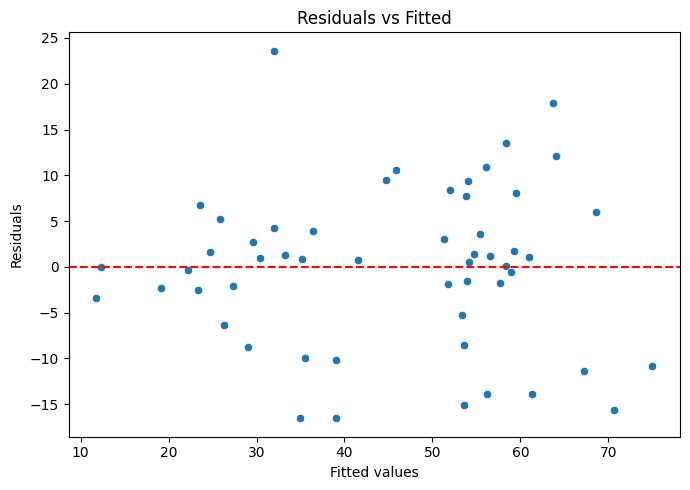

In [1130]:
fitted_vals = vif_clean_model.fittedvalues
residuals = vif_clean_model.resid

plt.figure(figsize=(7,5))
sns.scatterplot(x=fitted_vals, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.tight_layout()
plt.show()

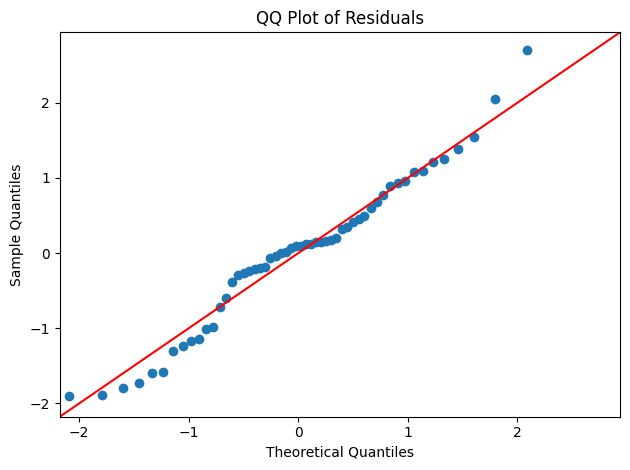

In [1131]:
sm.qqplot(vif_clean_model.resid, line='45', fit=True)
plt.title("QQ Plot of Residuals")
plt.tight_layout()
plt.show()

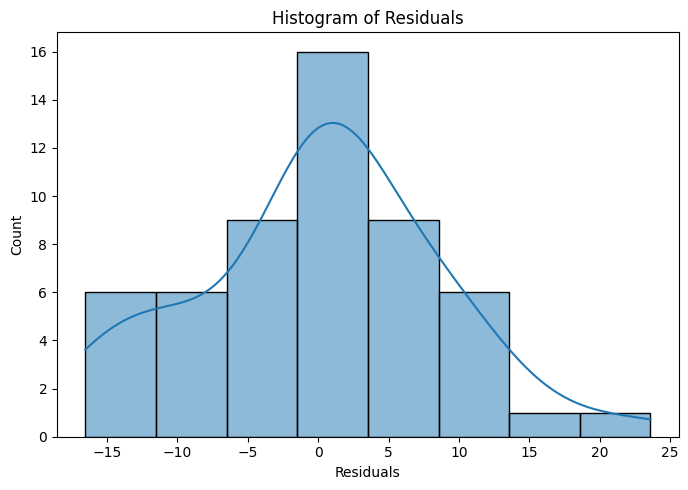

In [1132]:
plt.figure(figsize=(7,5))
sns.histplot(vif_clean_model.resid, kde=True)
plt.xlabel("Residuals")
plt.title("Histogram of Residuals")
plt.tight_layout()
plt.show()

/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/statsmodels/stats/outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)


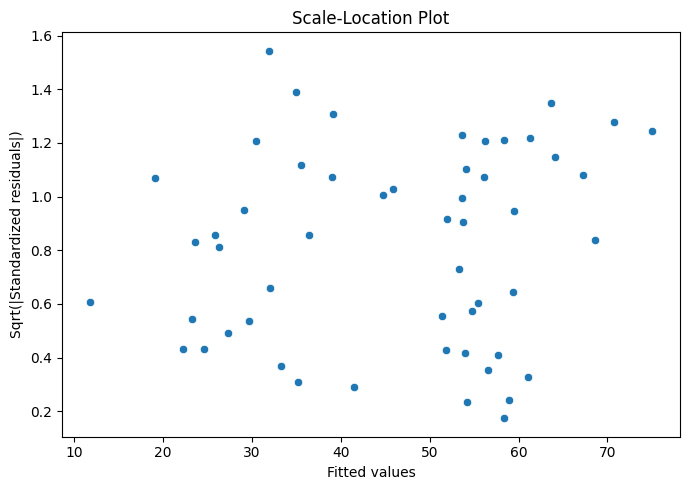

In [1133]:
influence = vif_clean_model.get_influence()
std_resid = influence.resid_studentized_internal
sqrt_abs_std_resid = np.sqrt(np.abs(std_resid))

plt.figure(figsize=(7,5))
sns.scatterplot(x=fitted_vals, y=sqrt_abs_std_resid)
plt.xlabel("Fitted values")
plt.ylabel("Sqrt(|Standardized residuals|)")
plt.title("Scale-Location Plot")
plt.tight_layout()
plt.show()

In [1134]:
bp_test = het_breuschpagan(vif_clean_model.resid, vif_clean_model.model.exog)

bp_results = pd.DataFrame({
    'Statistic': ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value'],
    'Value': bp_test
})

bp_results

,Statistic,Value
0,LM Statistic,8.447847
1,LM p-value,0.971197
2,F Statistic,0.360606
3,F p-value,0.987913


In [1135]:
dw_stat = durbin_watson(vif_clean_model.resid)
print("Durbin-Watson statistic:", round(dw_stat, 4))

Durbin-Watson statistic: 2.233


In [1136]:
residual_df = pd.DataFrame({
    'index': df_variance_clean.index,
    'fitted': vif_clean_model.fittedvalues,
    'residual': vif_clean_model.resid
})

residual_df.head()

,index,fitted,residual
0,0,31.981020,4.268980
1,1,53.343221,-5.243221
2,2,53.611628,-15.111628
3,3,44.720741,9.479259
4,4,26.300163,-6.300163


In [1137]:
from scipy.stats import shapiro

# Get residuals from the final OLS model
residuals = vif_clean_model.resid

# Apply Shapiro-Wilk normality test
shapiro_stat, shapiro_p = shapiro(residuals)

print("Shapiro-Wilk Test for Normality")
print(f"Test Statistic: {shapiro_stat:.4f}")
print(f"P-value: {shapiro_p:.4f}")

# Interpretation
alpha = 0.05

if shapiro_p > alpha:
    print("Residuals appear approximately normal (fail to reject H0).")
else:
    print("Residuals do not appear normal (reject H0).")

Shapiro-Wilk Test for Normality
Test Statistic: 0.9731
P-value: 0.2631
Residuals appear approximately normal (fail to reject H0).


In [1138]:
X_vif = X.drop(columns="const").copy()

vif_df = pd.DataFrame({
    "Predictor": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_df

,Predictor,VIF
1,student_disabilities_percent,15.603756
9,3-Methylhistidine (mg),9.416196
10,TRANS 18:1 (trans-octadecenoic acid) (g),8.226744
14,Mannitol (g),8.150423
2,HEI 2015 Greens and Beans (0-5),7.757536
15,Sorbitol (g),7.420981
7,Beta-Tocopherol (mg),6.789363
4,Whole Fruit Servings in cup equivalents per 10...,6.400199
5,Seafood and Plant Protein Servings in ounce eq...,6.366470
3,HEI 2015 Whole Grains (0-10),5.662012


In [1139]:
predictors_vif = [
    col for col in X
    if col not in [
        'student_disabilities_percent',
        '3-Methylhistidine (mg)',
        'TRANS 18:1 (trans-octadecenoic acid) (g)',
        'Mannitol (g)',
    ]
]

print(predictors_vif)

['const', 'student_low_income_percent', 'HEI 2015 Greens and Beans (0-5)', 'HEI 2015 Whole Grains (0-10)', 'Whole Fruit Servings in cup equivalents per 1000 kcal', 'Seafood and Plant Protein Servings in ounce equivalents per 1000 kcal', 'Galactose (g)', 'Beta-Tocopherol (mg)', 'Aspartame (mg)', 'Synthetic Alpha-Tocopherol (all rac-alpha-tocopherol or dl-alpha-tocopherol) (mg)', 'Daidzein (mg)', 'Biochanin A (mg)', 'Sorbitol (g)', 'Tagatose (mg)', 'Secoisolariciresinol (mcg)']


In [1140]:
Xnew = X[predictors_vif].copy()
ynew = df_variance_clean['Science_Proficiency'].copy()

Xnew = sm.add_constant(Xnew)
science_refit = sm.OLS(ynew, Xnew).fit()

print(science_refit.summary())

                             OLS Regression Results                            
Dep. Variable:     Science_Proficiency   R-squared:                       0.687
Model:                             OLS   Adj. R-squared:                  0.575
Method:                  Least Squares   F-statistic:                     6.112
Date:                 Sun, 26 Apr 2026   Prob (F-statistic):           3.57e-06
Time:                         12:55:04   Log-Likelihood:                -201.66
No. Observations:                   54   AIC:                             433.3
Df Residuals:                       39   BIC:                             463.2
Df Model:                           14                                         
Covariance Type:             nonrobust                                         
                                                                                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------

In [1141]:
X_vif = Xnew.drop(columns="const").copy()

vif_df = pd.DataFrame({
    "Predictor": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_df

,Predictor,VIF
1,HEI 2015 Greens and Beans (0-5),6.799510
4,Seafood and Plant Protein Servings in ounce eq...,5.839058
11,Sorbitol (g),5.691317
3,Whole Fruit Servings in cup equivalents per 10...,4.778027
6,Beta-Tocopherol (mg),4.501119
0,student_low_income_percent,3.971763
2,HEI 2015 Whole Grains (0-10),3.962523
10,Biochanin A (mg),2.606220
5,Galactose (g),2.568327
9,Daidzein (mg),1.794286


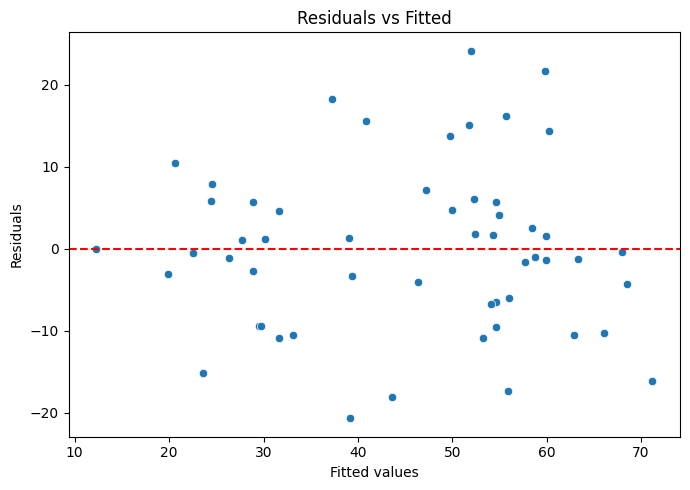

In [1142]:
fitted_vals = science_refit.fittedvalues
residuals = science_refit.resid

plt.figure(figsize=(7,5))
sns.scatterplot(x=fitted_vals, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.tight_layout()
plt.show()

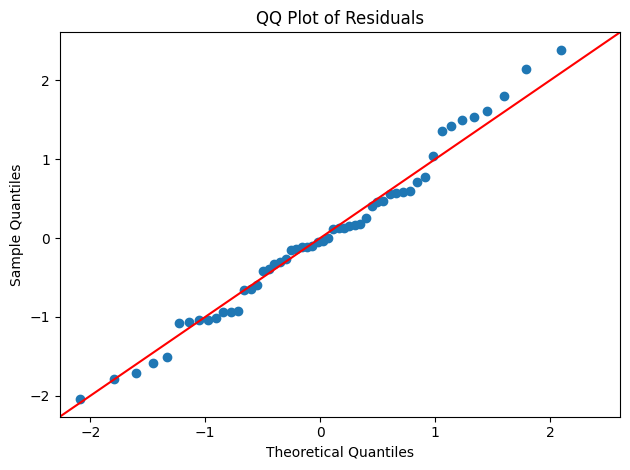

In [1143]:
sm.qqplot(science_refit.resid, line='45', fit=True)
plt.title("QQ Plot of Residuals")
plt.tight_layout()
plt.show()

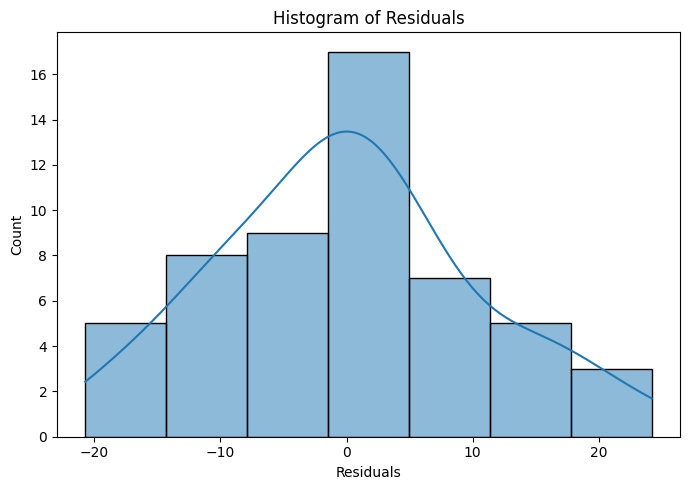

In [1144]:
plt.figure(figsize=(7,5))
sns.histplot(science_refit.resid, kde=True)
plt.xlabel("Residuals")
plt.title("Histogram of Residuals")
plt.tight_layout()
plt.show()

In [1145]:
bp_test = het_breuschpagan(science_refit.resid, science_refit.model.exog)

bp_results = pd.DataFrame({
    'Statistic': ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value'],
    'Value': bp_test
})

bp_results

,Statistic,Value
0,LM Statistic,6.714123
1,LM p-value,0.945171
2,F Statistic,0.395544
3,F p-value,0.967927


In [1146]:
# Get residuals from the final OLS model
residuals = science_refit.resid

# Apply Shapiro-Wilk normality test
shapiro_stat, shapiro_p = shapiro(residuals)

print("Shapiro-Wilk Test for Normality")
print(f"Test Statistic: {shapiro_stat:.4f}")
print(f"P-value: {shapiro_p:.4f}")

# Interpretation
alpha = 0.05

if shapiro_p > alpha:
    print("Residuals appear approximately normal (fail to reject H0).")
else:
    print("Residuals do not appear normal (reject H0).")

Shapiro-Wilk Test for Normality
Test Statistic: 0.9822
P-value: 0.5999
Residuals appear approximately normal (fail to reject H0).


### Model 2: Ridge

In [1147]:
vif_clean_nutrition_vars

['HEI 2015 Greens and Beans (0-5)',
 'HEI 2015 Whole Grains (0-10)',
 'Whole Fruit Servings in cup equivalents per 1000 kcal',
 'Seafood and Plant Protein Servings in ounce equivalents per 1000 kcal',
 'Galactose (g)',
 'Beta-Tocopherol (mg)',
 'Aspartame (mg)',
 '3-Methylhistidine (mg)',
 'TRANS 18:1 (trans-octadecenoic acid) (g)',
 'Synthetic Alpha-Tocopherol (all rac-alpha-tocopherol or dl-alpha-tocopherol) (mg)',
 'Daidzein (mg)',
 'Biochanin A (mg)',
 'Mannitol (g)',
 'Sorbitol (g)',
 'Tagatose (mg)',
 'Secoisolariciresinol (mcg)']

In [1148]:
# choose outcome
target_outcome = 'Science_Proficiency'   

# predictors: SES + filtered nutrition variables
ses_vars = ['student_low_income_percent', 'student_disabilities_percent']
ridge_predictors = ses_vars + vif_clean_nutrition_vars  

In [1149]:
# build X and y
X = df_variance_clean[ridge_predictors].copy()
y = df_variance_clean[target_outcome].copy()

In [1150]:
# scale X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [1151]:
# choose lambda (alpha) by cross-validation
alphas = np.logspace(-3, 3, 100)
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_scaled, y)

best_alpha = ridge_cv.alpha_
print("Best lambda (alpha):", best_alpha)

/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = 

Best lambda (alpha): 11.497569953977356


/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = 

In [1152]:
# fit final ridge model
ridge_model = Ridge(alpha=best_alpha)
ridge_model.fit(X_scaled, y)

# coefficient table
ridge_coef_table = pd.DataFrame({
    'Predictor': ridge_predictors,
    'Ridge_Coefficient': ridge_model.coef_
}).sort_values('Ridge_Coefficient', key=np.abs, ascending=False)

print("\nTop coefficients:")
print(ridge_coef_table.head(20))


Top coefficients:
                                            Predictor  Ridge_Coefficient
0                          student_low_income_percent          -7.945094
9                              3-Methylhistidine (mg)          -4.001433
2                     HEI 2015 Greens and Beans (0-5)          -3.882040
15                                       Sorbitol (g)          -3.266350
1                        student_disabilities_percent          -2.581873
3                        HEI 2015 Whole Grains (0-10)          -2.451718
8                                      Aspartame (mg)          -1.994397
5   Seafood and Plant Protein Servings in ounce eq...           1.833673
17                         Secoisolariciresinol (mcg)          -1.761822
6                                       Galactose (g)          -1.683608
11  Synthetic Alpha-Tocopherol (all rac-alpha-toco...          -1.470733
14                                       Mannitol (g)           1.464010
10           TRANS 18:1 (trans-o

In [1153]:
# cross-validated performance
cv_rmse = -cross_val_score(ridge_model, X_scaled, y, cv=5, scoring='neg_root_mean_squared_error')
cv_mae = -cross_val_score(ridge_model, X_scaled, y, cv=5, scoring='neg_mean_absolute_error')
cv_r2 = cross_val_score(ridge_model, X_scaled, y, cv=5, scoring='r2')

print("\nCV RMSE mean:", round(cv_rmse.mean(), 4))
print("CV MAE mean:", round(cv_mae.mean(), 4))
print("CV R^2 mean:", round(cv_r2.mean(), 4))


CV RMSE mean: 12.9356
CV MAE mean: 10.769
CV R^2 mean: 0.4743


/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = 

In [1154]:
zero_pct = (X == 0).mean().sort_values(ascending=False)
zero_pct.head(20)

Aspartame (mg)                                                                       0.981481
Synthetic Alpha-Tocopherol (all rac-alpha-tocopherol or dl-alpha-tocopherol) (mg)    0.925926
Whole Fruit Servings in cup equivalents per 1000 kcal                                0.055556
HEI 2015 Greens and Beans (0-5)                                                      0.037037
Seafood and Plant Protein Servings in ounce equivalents per 1000 kcal                0.037037
Biochanin A (mg)                                                                     0.018519
student_low_income_percent                                                           0.000000
Tagatose (mg)                                                                        0.000000
Sorbitol (g)                                                                         0.000000
Mannitol (g)                                                                         0.000000
Daidzein (mg)                                               

In [1155]:
target_outcome = 'Science_Proficiency'

ses_vars = ['student_low_income_percent', 'student_disabilities_percent']
ridge_predictors = ses_vars + vif_clean_nutrition_vars

X = df_variance_clean[ridge_predictors].copy()
y = df_variance_clean[target_outcome].copy()

# remove sparse variables (>80% zeros), except SES
zero_pct = (X == 0).mean()
sparse_drop = [col for col in X.columns if col not in ses_vars and zero_pct[col] > 0.80]

# manually remove highly skewed / unstable niche variables
manual_drop = [
    'Daidzein (mg)',
    'Tagatose (mg)',
    'Secoisolariciresinol (mcg)',
    'Biochanin A (mg)'
]

In [1156]:
manual_drop = [col for col in manual_drop if col in X.columns]

drop_cols = list(set(sparse_drop + manual_drop))
X = X.drop(columns=drop_cols)

print("Dropped columns:")
print(drop_cols)

# log-transform nonnegative non-SES predictors
X_clean = X.copy()
for col in X_clean.columns:
    if col not in ses_vars and (X_clean[col] >= 0).all():
        X_clean[col] = np.log1p(X_clean[col])

# scale predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

Dropped columns:
['Biochanin A (mg)', 'Tagatose (mg)', 'Secoisolariciresinol (mcg)', 'Synthetic Alpha-Tocopherol (all rac-alpha-tocopherol or dl-alpha-tocopherol) (mg)', 'Daidzein (mg)', 'Aspartame (mg)']


In [1157]:
# choose best lambda using CV
alphas = np.logspace(-3, 3, 100)
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_scaled, y)

best_alpha = ridge_cv.alpha_
print("Best lambda (alpha):", best_alpha)

/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = 

Best lambda (alpha): 8.697490026177835


/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = 

In [1158]:
# fit final ridge model
ridge_model_clean = Ridge(alpha=best_alpha)
ridge_model_clean.fit(X_scaled, y)

# coefficient table
ridge_coef_table_clean = pd.DataFrame({
    'Predictor': X_clean.columns,
    'Ridge_Coefficient': ridge_model_clean.coef_
}).sort_values('Ridge_Coefficient', key=np.abs, ascending=False)

print("\nTop coefficients:")
print(ridge_coef_table_clean.head(20))


Top coefficients:
                                            Predictor  Ridge_Coefficient
0                          student_low_income_percent          -8.899376
2                     HEI 2015 Greens and Beans (0-5)          -4.299396
11                                       Sorbitol (g)          -3.724939
8                              3-Methylhistidine (mg)          -3.494695
3                        HEI 2015 Whole Grains (0-10)          -2.835693
1                        student_disabilities_percent          -2.596122
5   Seafood and Plant Protein Servings in ounce eq...           2.009115
6                                       Galactose (g)          -1.937444
9            TRANS 18:1 (trans-octadecenoic acid) (g)           1.920436
10                                       Mannitol (g)           1.744134
4   Whole Fruit Servings in cup equivalents per 10...          -0.854646
7                                Beta-Tocopherol (mg)           0.173640


In [1159]:
# cross-validated performance
cv_rmse = -cross_val_score(ridge_model_clean, X_scaled, y, cv=5, scoring='neg_root_mean_squared_error')
cv_mae = -cross_val_score(ridge_model_clean, X_scaled, y, cv=5, scoring='neg_mean_absolute_error')
cv_r2 = cross_val_score(ridge_model_clean, X_scaled, y, cv=5, scoring='r2')

print("\nCV RMSE mean:", round(cv_rmse.mean(), 4))
print("CV MAE mean:", round(cv_mae.mean(), 4))
print("CV R^2 mean:", round(cv_r2.mean(), 4))


CV RMSE mean: 12.0597
CV MAE mean: 10.1005
CV R^2 mean: 0.5405


/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = 

### Lasso on all predictors 

In [1160]:
df_variance_clean.columns

Index(['student_disabilities_percent', 'student_low_income_percent',
       'HEI 2015 Total Score', 'HEI 2015 Total Fruits (0-5)',
       'HEI 2015 Whole Fruits (0-5)', 'HEI 2015 Total Vegetables (0-5)',
       'HEI 2015 Greens and Beans (0-5)', 'HEI 2015 Whole Grains (0-10)',
       'HEI 2015 Dairy (0-10)', 'HEI 2015 Total Protein Foods (0-5)',
       ...
       'Total Lignans (mcg)', 'Secoisolariciresinol (mcg)',
       'Matairesinol (mcg)', 'Lariciresinol (mcg)', 'Pinoresinol (mcg)',
       'PUFA 18:2 n-6 (linoleic acid [LA]) (g)', 'Omega-6 Fatty Acids (g)',
       'ELA_Proficiency', 'Math_Proficiency', 'Science_Proficiency'],
      dtype='object', length=191)

In [1161]:
df = df_variance_clean.copy()

target = 'Science_Proficiency'
outcome_cols = ['ELA_Proficiency', 'Math_Proficiency', 'Science_Proficiency']

In [1162]:
df = df_variance_clean.copy() 

target = 'Science_Proficiency'
outcome_cols = ['ELA_Proficiency', 'Math_Proficiency', 'Science_Proficiency']

predictors = [col for col in df.columns if col not in outcome_cols]

print("Number of predictors:", len(predictors))

Number of predictors: 188


In [1163]:
X = df[predictors].copy()
y = df[target].copy()

print(X.shape)
print(y.shape)

(54, 188)
(54,)


In [1164]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [1165]:
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_scaled, y)

best_alpha = lasso_cv.alpha_
print("Best lambda (alpha):", best_alpha)

Best lambda (alpha): 1.638743967782501


In [1166]:
lasso_model = Lasso(alpha=best_alpha, max_iter=10000)
lasso_model.fit(X_scaled, y)

Lasso(alpha=np.float64(1.638743967782501), max_iter=10000)

In [1167]:
lasso_coef_table = pd.DataFrame({
    'Predictor': X.columns,
    'Lasso_Coefficient': lasso_model.coef_
}).sort_values('Lasso_Coefficient', key=np.abs, ascending=False)

lasso_coef_table.head(30)

,Predictor,Lasso_Coefficient
1,student_low_income_percent,-9.816000
141,Alpha-Carotene (provitamin A carotenoid) (mcg),-1.984017
126,3-Methylhistidine (mg),-1.835769
29,Total Fruit Servings in cup equivalents,-1.243311
0,student_disabilities_percent,-1.228754
15,HEI 2015 Saturated Fats (0-10),1.200920
6,HEI 2015 Greens and Beans (0-5),-0.903122
20,Whole Grain Servings in ounce equivalents per ...,-0.777181
122,Aspartame (mg),-0.565803
171,Sorbitol (g),-0.469638


In [1168]:
lasso_selected = lasso_coef_table[lasso_coef_table['Lasso_Coefficient'] != 0].copy()
lasso_selected

,Predictor,Lasso_Coefficient
1,student_low_income_percent,-9.816000
141,Alpha-Carotene (provitamin A carotenoid) (mcg),-1.984017
126,3-Methylhistidine (mg),-1.835769
29,Total Fruit Servings in cup equivalents,-1.243311
0,student_disabilities_percent,-1.228754
15,HEI 2015 Saturated Fats (0-10),1.200920
6,HEI 2015 Greens and Beans (0-5),-0.903122
20,Whole Grain Servings in ounce equivalents per ...,-0.777181
122,Aspartame (mg),-0.565803
171,Sorbitol (g),-0.469638


In [1169]:
selected_predictors = lasso_selected['Predictor'].tolist()

print("Selected predictors:")
print(selected_predictors)
print("Number selected:", len(selected_predictors))

Selected predictors:
['student_low_income_percent', 'Alpha-Carotene (provitamin A carotenoid) (mcg)', '3-Methylhistidine (mg)', 'Total Fruit Servings in cup equivalents', 'student_disabilities_percent', 'HEI 2015 Saturated Fats (0-10)', 'HEI 2015 Greens and Beans (0-5)', 'Whole Grain Servings in ounce equivalents per 1000 kcal', 'Aspartame (mg)', 'Sorbitol (g)', 'HEI 2015 Refined Grains (0-10)', 'Acesulfame Potassium (mg)', 'Maltose (g)', 'Secoisolariciresinol (mcg)']
Number selected: 14


In [1170]:
X_ols = df[selected_predictors].copy()
y_ols = df[target].copy()

X_ols = sm.add_constant(X_ols)
lasso_ols_model = sm.OLS(y_ols, X_ols).fit()

print(lasso_ols_model.summary())

                             OLS Regression Results                            
Dep. Variable:     Science_Proficiency   R-squared:                       0.752
Model:                             OLS   Adj. R-squared:                  0.672
Method:                  Least Squares   F-statistic:                     9.353
Date:                 Sun, 26 Apr 2026   Prob (F-statistic):           1.92e-08
Time:                         12:55:06   Log-Likelihood:                -195.32
No. Observations:                   54   AIC:                             418.6
Df Residuals:                       40   BIC:                             446.5
Df Model:                           13                                         
Covariance Type:             nonrobust                                         
                                                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

In [1171]:
cv_rmse = -cross_val_score(lasso_model, X_scaled, y, cv=5, scoring='neg_root_mean_squared_error')
cv_mae = -cross_val_score(lasso_model, X_scaled, y, cv=5, scoring='neg_mean_absolute_error')
cv_r2 = cross_val_score(lasso_model, X_scaled, y, cv=5, scoring='r2')

print("CV RMSE mean:", round(cv_rmse.mean(), 4))
print("CV MAE mean:", round(cv_mae.mean(), 4))
print("CV R^2 mean:", round(cv_r2.mean(), 4))

CV RMSE mean: 13.0857
CV MAE mean: 10.5911
CV R^2 mean: 0.4616


/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ishita/Coder/Pro

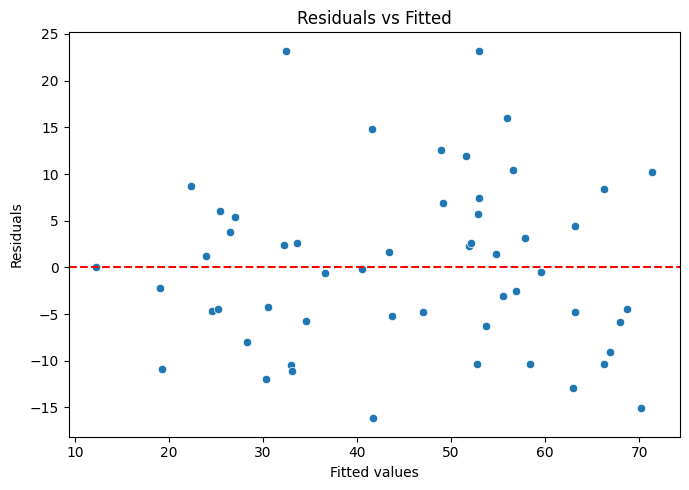

In [1172]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=lasso_ols_model.fittedvalues, y=lasso_ols_model.resid)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.tight_layout()
plt.show()

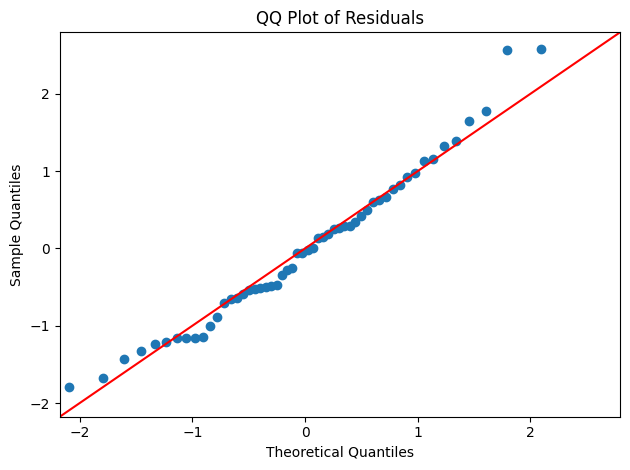

In [1173]:
sm.qqplot(lasso_ols_model.resid, line='45', fit=True)
plt.title("QQ Plot of Residuals")
plt.tight_layout()
plt.show()

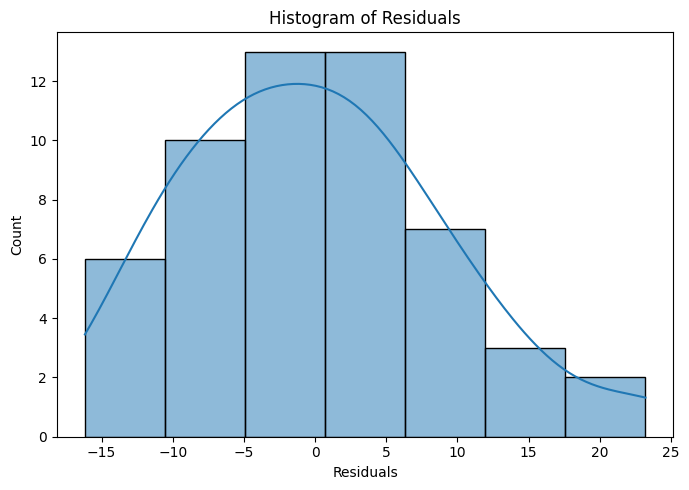

In [1174]:
plt.figure(figsize=(7,5))
sns.histplot(lasso_ols_model.resid, kde=True)
plt.xlabel("Residuals")
plt.title("Histogram of Residuals")
plt.tight_layout()
plt.show()

In [1175]:
X_vif = X_ols.drop(columns="const").copy()

vif_df = pd.DataFrame({
    "Predictor": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_df

/Users/ishita/Coder/Proj/STUDENT-MEALS-/venv/lib/python3.9/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Predictor,VIF
8,Aspartame (mg),inf
11,Acesulfame Potassium (mg),inf
5,HEI 2015 Saturated Fats (0-10),16.445758
4,student_disabilities_percent,15.513743
10,HEI 2015 Refined Grains (0-10),13.187197
3,Total Fruit Servings in cup equivalents,10.236969
9,Sorbitol (g),7.086970
2,3-Methylhistidine (mg),6.731491
1,Alpha-Carotene (provitamin A carotenoid) (mcg),6.275842
12,Maltose (g),6.171477


In [1176]:
bp_test = het_breuschpagan(lasso_ols_model.resid, lasso_ols_model.model.exog)

bp_results = pd.DataFrame({
    "Statistic": ["LM Statistic", "LM p-value", "F Statistic", "F p-value"],
    "Value": bp_test
})

bp_results

,Statistic,Value
0,LM Statistic,11.888654
1,LM p-value,0.615244
2,F Statistic,0.868661
3,F p-value,0.590026


In [1177]:
# Get residuals from the final OLS model
residuals = lasso_ols_model.resid

# Apply Shapiro-Wilk normality test
shapiro_stat, shapiro_p = shapiro(residuals)

print("Shapiro-Wilk Test for Normality")
print(f"Test Statistic: {shapiro_stat:.4f}")
print(f"P-value: {shapiro_p:.4f}")

# Interpretation
alpha = 0.05

if shapiro_p > alpha:
    print("Residuals appear approximately normal (fail to reject H0).")
else:
    print("Residuals do not appear normal (reject H0).")

Shapiro-Wilk Test for Normality
Test Statistic: 0.9728
P-value: 0.2542
Residuals appear approximately normal (fail to reject H0).


### Fitting lasso model after handling VIF

In [1178]:
predictors_step2 = [
    col for col in selected_predictors
    if col not in [
        'Aspartame (mg)',
        'Acesulfame Potassium (mg)',
        'HEI 2015 Saturated Fats (0-10)',
        'student_disabilities_percent',
        'HEI 2015 Refined Grains (0-10)',
        'Total Fruit Servings in cup equivalents'
    ]
]

print(predictors_step2)

['student_low_income_percent', 'Alpha-Carotene (provitamin A carotenoid) (mcg)', '3-Methylhistidine (mg)', 'HEI 2015 Greens and Beans (0-5)', 'Whole Grain Servings in ounce equivalents per 1000 kcal', 'Sorbitol (g)', 'Maltose (g)', 'Secoisolariciresinol (mcg)']


In [1179]:
X2 = df[predictors_step2].copy()
y2 = df['Science_Proficiency'].copy()

X2 = sm.add_constant(X2)
science_lasso_ols_clean2 = sm.OLS(y2, X2).fit()

print(science_lasso_ols_clean2.summary())

                             OLS Regression Results                            
Dep. Variable:     Science_Proficiency   R-squared:                       0.673
Model:                             OLS   Adj. R-squared:                  0.615
Method:                  Least Squares   F-statistic:                     11.59
Date:                 Sun, 26 Apr 2026   Prob (F-statistic):           9.35e-09
Time:                         12:55:06   Log-Likelihood:                -202.82
No. Observations:                   54   AIC:                             423.6
Df Residuals:                       45   BIC:                             441.5
Df Model:                            8                                         
Covariance Type:             nonrobust                                         
                                                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

In [1180]:
X_vif = X2.drop(columns="const").copy()

vif_df = pd.DataFrame({
    "Predictor": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_df

,Predictor,VIF
1,Alpha-Carotene (provitamin A carotenoid) (mcg),5.729527
6,Maltose (g),5.545563
2,3-Methylhistidine (mg),4.711632
5,Sorbitol (g),4.069512
3,HEI 2015 Greens and Beans (0-5),3.591261
0,student_low_income_percent,3.474162
4,Whole Grain Servings in ounce equivalents per ...,2.829887
7,Secoisolariciresinol (mcg),1.429684


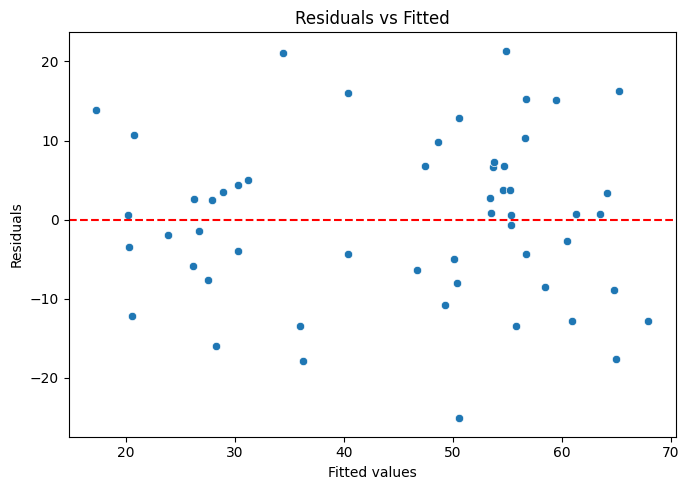

In [1181]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=science_lasso_ols_clean2.fittedvalues, y=science_lasso_ols_clean2.resid)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.tight_layout()
plt.show()

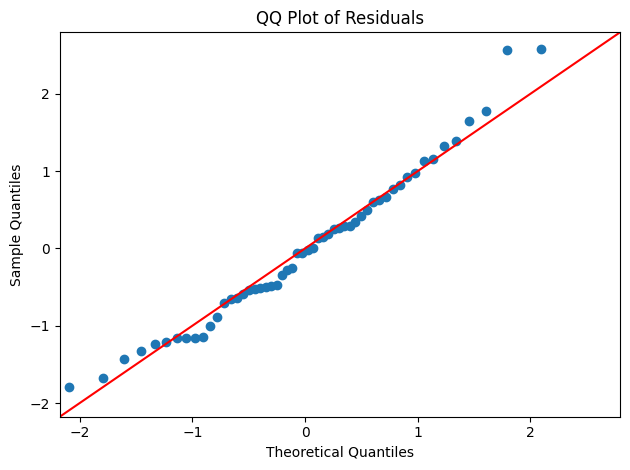

In [1182]:
sm.qqplot(lasso_ols_model.resid, line='45', fit=True)
plt.title("QQ Plot of Residuals")
plt.tight_layout()
plt.show()

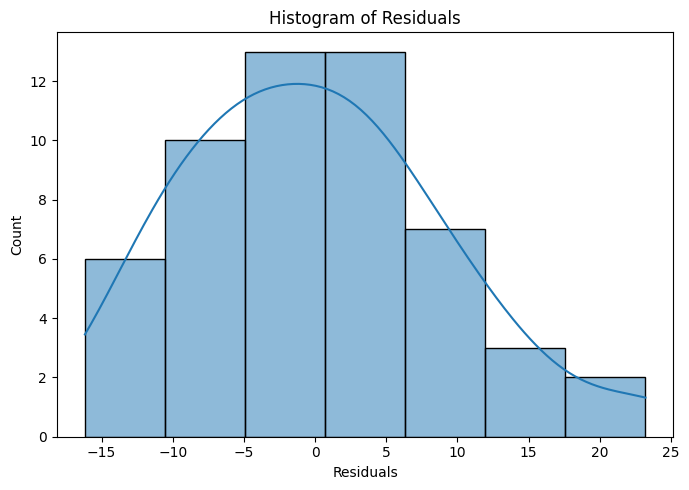

In [1183]:
plt.figure(figsize=(7,5))
sns.histplot(lasso_ols_model.resid, kde=True)
plt.xlabel("Residuals")
plt.title("Histogram of Residuals")
plt.tight_layout()
plt.show()

In [1184]:
bp_test = het_breuschpagan(lasso_ols_model.resid, lasso_ols_model.model.exog)

bp_results = pd.DataFrame({
    "Statistic": ["LM Statistic", "LM p-value", "F Statistic", "F p-value"],
    "Value": bp_test
})

bp_results

,Statistic,Value
0,LM Statistic,11.888654
1,LM p-value,0.615244
2,F Statistic,0.868661
3,F p-value,0.590026


In [1185]:
# Get residuals from the final OLS model
residuals = lasso_ols_model.resid

# Apply Shapiro-Wilk normality test
shapiro_stat, shapiro_p = shapiro(residuals)

print("Shapiro-Wilk Test for Normality")
print(f"Test Statistic: {shapiro_stat:.4f}")
print(f"P-value: {shapiro_p:.4f}")

# Interpretation
alpha = 0.05

if shapiro_p > alpha:
    print("Residuals appear approximately normal (fail to reject H0).")
else:
    print("Residuals do not appear normal (reject H0).")

Shapiro-Wilk Test for Normality
Test Statistic: 0.9728
P-value: 0.2542
Residuals appear approximately normal (fail to reject H0).
